<a href="https://colab.research.google.com/github/tomasrodriguezr11/Programacion-MIAAD/blob/main/Practica01_Semana10_266228.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 01 - Semana 10: Normalización y transformación de datos**
**Programación para analítica descriptiva y predictiva MIAAD**

*Realizada por: Tomás Eduardo Rodríguez Ramírez*

*Número de matrícula: 266228*

#Ejercicio 1: Normalización Min-Max

1.	Cargar el dataset wine de sklearn.


```python
from sklearn.datasets import load_wine
# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target
```


2.	Seleccionar una de las características numéricas (por ejemplo, alcohol).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Min-Max a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la normalización?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from scipy.stats import shapiro
from sklearn.preprocessing import MinMaxScaler

# Carga de datos
wine = load_wine()
X = wine.data

In [2]:
# Selección de característica numérica (alcohol = columna 0)
alcohol = X[:, 0]

In [3]:
# Normalidad de datos originales
stat1, p1 = shapiro(alcohol)

In [4]:
# Normalización Min-Max a los datos seleccionados
scaler = MinMaxScaler()
alcohol_norm = scaler.fit_transform(alcohol.reshape(-1,1)).flatten()

In [5]:
# Normalidad sobre datos normalizados
stat2, p2 = shapiro(alcohol_norm)

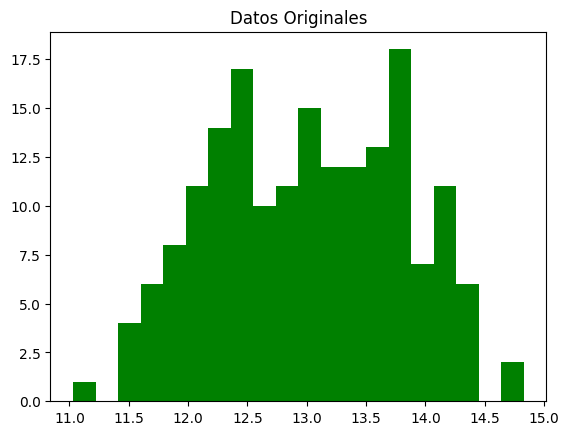

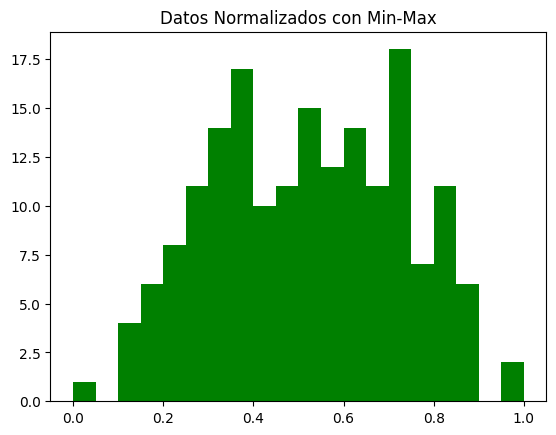

6.966496130945429e-41 0.9891215954703348


In [26]:
# Gráficas de datos originales y datos normalizados
plt.hist(alcohol, bins=20, color="green")
plt.title("Datos Originales")
plt.show()

plt.hist(alcohol_norm, bins=20, color="green")
plt.title("Datos Normalizados con Min-Max")
plt.show()

print(p1, p2)

**1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?**

No cambia la forma de la distribución. Solo reescala los datos al rango [0,1]. La distribución sigue siendo igual (sesgada o no normal).

**2. ¿Qué interpretas del p-valor antes y después de la normalización?**

El p-valor prácticamente no cambia, la normalización no vuelve normales los datos, solo cambia la escala.

# Ejercicio 2: Normalización Z-Score

Instrucciones:
1. Cargar el dataset wine de sklearn.
2. Seleccionar una de las características numéricas (por ejemplo, malic_acid).
3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4. Aplicar la normalización Z-Score a los datos seleccionados.
5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7. Responder las preguntas siguientes.

Preguntas:
1. ¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?
2. ¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?



In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
# Selección de característica numérica (malic_acid = columna 1)
malic = X[:, 1]

In [9]:
# Normalidad de datos originales
stat1, p1 = shapiro(malic)

In [10]:
# Normalización Z-score a los datos seleccionados
scaler = StandardScaler()
malic_z = scaler.fit_transform(malic.reshape(-1,1)).flatten()

In [11]:
# Normalidad de datos normalizados
stat2, p2 = shapiro(malic_z)

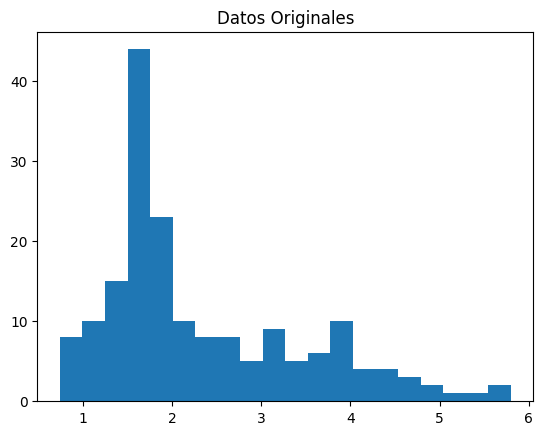

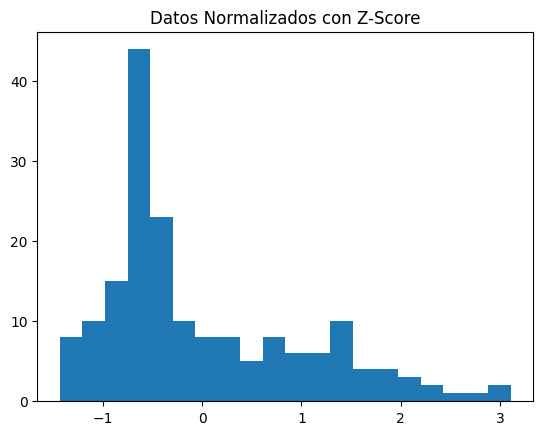

2.945800703600761e-10 2.9458007036005247e-10


In [12]:
# Gráficas de datos originales y normalizados
plt.hist(malic, bins=20)
plt.title("Datos Originales")
plt.show()

plt.hist(malic_z, bins=20)
plt.title("Datos Normalizados con Z-Score")
plt.show()

print(p1, p2)

**1. ¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?**

La forma de la distribución es la misma, pero ahora los datos están centrados en 0 con desviación estándar 1.

**2. ¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?**

- Mejora el rendimiento de modelos (ej. regresión, SVM, redes neuronales).
- Hace comparables variables en distintas escalas.
- No corrige la normalidad.

#Ejercicio 3: Transformación Logarítmica
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy:
    - Número de observaciones = 1000;
    - Valor de semilla = `np.random.seed(42)`
    - Distribucion exponencial: `np.random.exponential(scale=2, size=1000)`
2. Aplicar una transformación logarítmica (np.log) a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación logarítmica a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la transformación logarítmica?


In [13]:
# Carga de datos aleatorios
np.random.seed(42)
data = np.random.exponential(scale=2, size=1000)

In [14]:
# Transformación logarítmica
log_data = np.log(data)

In [15]:
# Normalidad sobre datos originales y transformados
p1 = shapiro(data)[1]
p2 = shapiro(log_data)[1]

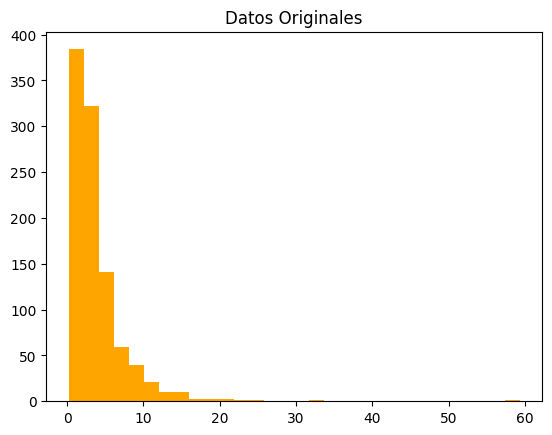

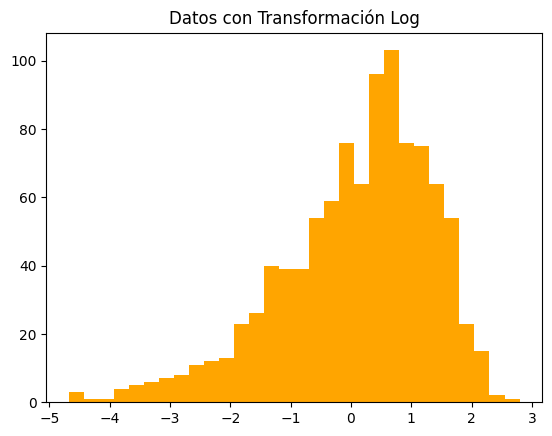

6.966496130945429e-41 0.9891215954703348


In [28]:
# Gráficas de datos originales y transformados
plt.hist(data, bins=30, color="orange")
plt.title("Datos Originales")
plt.show()

plt.hist(log_data, bins=30, color="orange")
plt.title("Datos con Transformación Log")
plt.show()

print(p1, p2)

**1. ¿Cómo afectó la transformación logarítmica a la distribución de los datos?**

Reduce el sesgo hacia la derecha (asimetría). Hace la distribución más simétrica.

**2. ¿Qué interpretas del p-valor antes y después de la transformación logarítmica?**

El p-valor aumenta, esto es, los datos se vuelven más cercanos a una distribución normal.

#Ejercicio 4: Transformación Raíz Cuadrada
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Número de observaciones: 1000
    - Semilla = `np.random.seed(42)``
    - Distribución Poisson: `np.random.poisson(lam=5, size=1000)`
2. Aplicar una transformación de raíz cuadrada a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?
2. ¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?


In [18]:
# Carga de datos aleatorios
np.random.seed(42)
data = np.random.poisson(lam=5, size=1000)

In [19]:
# Transformación con raíz cuadrada
sqrt_data = np.sqrt(data)

In [20]:
# Normalidad sobre los datos originales y transformados
p1 = shapiro(data)[1]
p2 = shapiro(sqrt_data)[1]

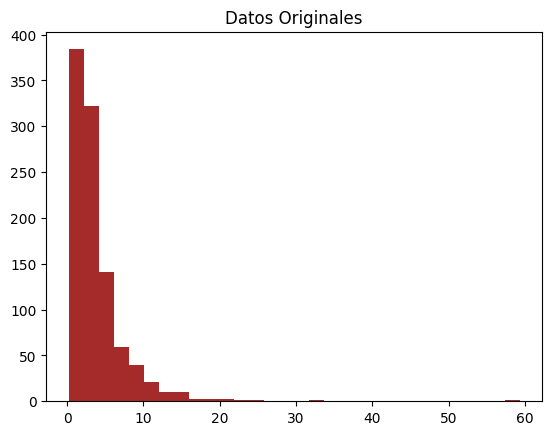

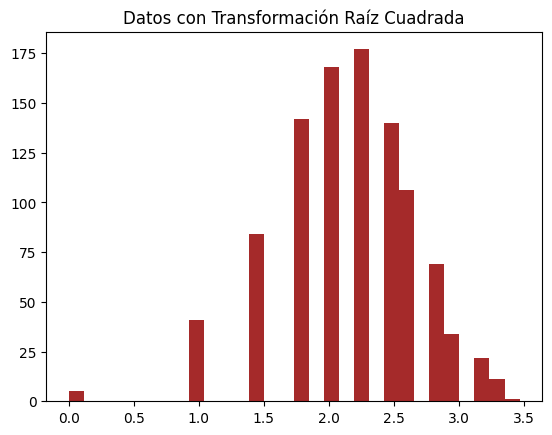

6.966496130945429e-41 0.9891215954703348


In [30]:
# Gráficas de datos originales y transformados
plt.hist(data, bins=30, color="brown")
plt.title("Datos Originales")
plt.show()

plt.hist(sqrt_data, bins=30, color="brown")
plt.title("Datos con Transformación Raíz Cuadrada")
plt.show()

print(p1, p2)

**1. ¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?**

Reduce la asimetría, pero menos que la transformación log

**2. ¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?**

Comprime valores grandes, esto es, reduce impacto de outliers.

#Ejercicio 5: Transformación Box-Cox
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Numero de observaciones: 1000
    - Semilla: `np.random.seed(42)``
    - Distribución log-normal: `np.random.lognormal(mean=1, sigma=0.8, size=1000)`
2. Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación Box-Cox a la distribución de los datos?
2. ¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?


In [22]:
# Carga de datos aleatorios
from scipy.stats import boxcox

np.random.seed(42)
data = np.random.lognormal(mean=1, sigma=0.8, size=1000)

In [23]:
# Transformación Box-Cox
data_boxcox, lam = boxcox(data)

In [24]:
# Prueba de normalidad sobre los datos originales y transformados
p1 = shapiro(data)[1]
p2 = shapiro(data_boxcox)[1]

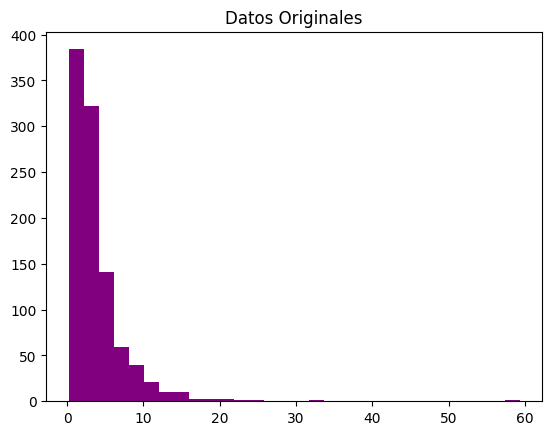

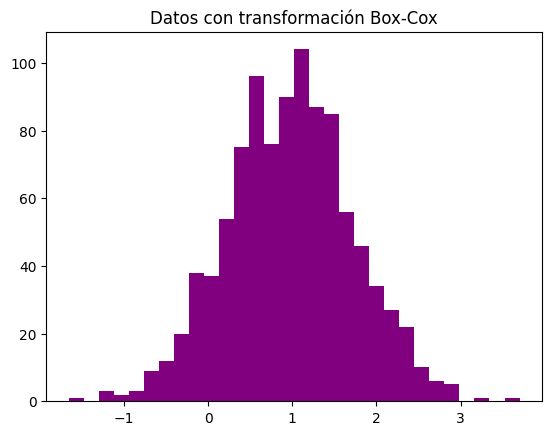

6.966496130945429e-41 0.9891215954703348 -0.04889276450171702


In [32]:
# Gráficos de datos originales y transformados
plt.hist(data, bins=30, color="purple")
plt.title("Datos Originales")
plt.show()

plt.hist(data_boxcox, bins=30, color="purple")
plt.title("Datos con transformación Box-Cox")
plt.show()

print(p1, p2, lam)

**1. ¿Cómo afectó la transformación Box-Cox a la distribución de los datos?**

Box-Cox transforma los datos para hacerlos lo más normales posible. Es más flexible que log o raíz.

**2. ¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?**

Lambda es un parámetro que optimiza la normalidad, se interpreta de la siguiente manera:

- λ ≈ 0 → transformación log
- λ ≈ 0.5 → raíz cuadrada
- λ ≈ 1 → sin transformación

